# XGBoost Standalone Model
Using final_features_1.csv with engineered features optimized for tree-based models

### 1. Load and Prepare Data

In [151]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

# ========== CONFIGURATION: CHANGE THESE VALUES ==========
# Choose which dataset to use: 1, 2, or 3
DATASET_VERSION = 2  # Change this to 2 or 3 to test other feature sets

# Define features for each dataset
FEATURE_CONFIGS = {
    1: {
        'file': '../data/final_features_1.csv',
        'features': [
            "season",
            "platt_apag_mom_pct",
            "platt_crude_mom_pct",
            "temp_avg",
            "precip_avg",
            "threshold_temp_days",
            "threshold_rainy_days",
            "possible_working_days",
            "avg_weight"
        ],
        'name': 'final_features_1.csv'
    },
    2: {
        'file': '../data/final_features_2.csv',
        'features': [
            "quarter",
            "season_sin",
            "season_cos",
            "temp_avg",
            "precip_avg",
            "possible_working_days",
            "avg_weight",
            "ap_price_weight",
            "crude_price_weight"
        ],
        'name': 'final_features_2.csv'
    },
}
# ========================================================

# Load selected dataset
config = FEATURE_CONFIGS[DATASET_VERSION]
df = pd.read_csv(config['file'])
df["ds"] = pd.to_datetime(df["date"], format="%Y%m") + pd.offsets.MonthEnd(0)
feature_cols = config['features']
dataset_name = config['name']

# Ensure numeric types
for col in feature_cols:
    df[col] = df[col].astype(float)

# Train/validation split (last 32 months for validation)
cutoff = df["ds"].max() - pd.DateOffset(months=32)
df_train = df[df["ds"] <= cutoff].copy()
df_valid = df[df["ds"] > cutoff].copy()

print(f"Using dataset: {dataset_name}")
print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")
print(f"\nTraining set: {len(df_train)} samples ({df_train['ds'].min()} to {df_train['ds'].max()})")
print(f"Validation set: {len(df_valid)} samples ({df_valid['ds'].min()} to {df_valid['ds'].max()})")

Using dataset: final_features_2.csv
Number of features: 9
Features: ['quarter', 'season_sin', 'season_cos', 'temp_avg', 'precip_avg', 'possible_working_days', 'avg_weight', 'ap_price_weight', 'crude_price_weight']

Training set: 264 samples (2001-01-31 00:00:00 to 2022-12-31 00:00:00)
Validation set: 32 samples (2023-01-31 00:00:00 to 2025-08-31 00:00:00)


### 2. Add Simple Time Features

In [152]:
# Extract time features
df_train["year"] = df_train["ds"].dt.year
df_train["month"] = df_train["ds"].dt.month

df_valid["year"] = df_valid["ds"].dt.year
df_valid["month"] = df_valid["ds"].dt.month

# All features: original features + time features
time_features = ['year', 'month']
all_features = feature_cols + time_features

print(f"\nTotal features: {len(all_features)}")
print(f"Feature list: {all_features}")


Total features: 11
Feature list: ['quarter', 'season_sin', 'season_cos', 'temp_avg', 'precip_avg', 'possible_working_days', 'avg_weight', 'ap_price_weight', 'crude_price_weight', 'year', 'month']


### 3. Prepare Data for XGBoost

In [153]:
# Prepare training and validation sets
X_train = df_train[all_features]
y_train = df_train["demand"]

X_valid = df_valid[all_features]
y_valid = df_valid["demand"]

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_valid)}")

Training samples: 264
Validation samples: 32


### 4. Hyperparameter Tuning

In [154]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

# Define parameter distribution for random search
param_distributions = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1, 0.15],
    'n_estimators': [300, 500, 700, 1000],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 1.5, 2.0]
}

# Base model
base_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Random search with cross-validation
# Using 3-fold CV to save time (can increase for more robust results)
print("Starting hyperparameter tuning...")
print("This may take several minutes...\n")

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter combinations to try
    scoring='neg_mean_squared_error',
    cv=3,  # 3-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the random search
random_search.fit(X_train, y_train)

print("\n" + "="*60)
print("Best Parameters Found:")
print("="*60)
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV Score (negative MSE): {random_search.best_score_:.2f}")
print(f"Best RMSE: {np.sqrt(-random_search.best_score_):,.2f}")

# Store best model
best_model = random_search.best_estimator_

Starting hyperparameter tuning...
This may take several minutes...

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best Parameters Found:
  subsample: 0.9
  reg_lambda: 0.5
  reg_alpha: 0
  n_estimators: 300
  min_child_weight: 5
  max_depth: 4
  learning_rate: 0.01
  gamma: 0.3
  colsample_bytree: 0.6

Best CV Score (negative MSE): -686035718.14
Best RMSE: 26,192.28


In [155]:
# Optional: Visualize tuning results
results_df = pd.DataFrame(random_search.cv_results_)
results_df['mean_rmse'] = np.sqrt(-results_df['mean_test_score'])
results_df = results_df.sort_values('mean_rmse')

print("\nTop 5 Parameter Combinations:")
print("="*60)
top_5 = results_df.head(5)[['mean_rmse', 'params']]
for idx, row in top_5.iterrows():
    print(f"\nRMSE: {row['mean_rmse']:,.2f}")
    print(f"Params: {row['params']}")


Top 5 Parameter Combinations:

RMSE: 26,192.28
Params: {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.6}

RMSE: 26,979.61
Params: {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.6}

RMSE: 27,112.58
Params: {'subsample': 0.9, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.7}

RMSE: 27,123.78
Params: {'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alpha': 0.01, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.7}

RMSE: 27,223.69
Params: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate':

### 5. Train Final Model with Best Parameters

In [156]:
# Train final model with best parameters and early stopping
model = xgb.XGBRegressor(
    **random_search.best_params_,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

# Train with validation monitoring
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=50
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best score: {model.best_score:.4f}")

[0]	validation_0-rmse:50779.11041	validation_1-rmse:47659.21085
[50]	validation_0-rmse:35576.41235	validation_1-rmse:34725.11340
[100]	validation_0-rmse:27103.48342	validation_1-rmse:27740.72281
[150]	validation_0-rmse:22339.77644	validation_1-rmse:23575.49330
[200]	validation_0-rmse:19635.70443	validation_1-rmse:21782.25143
[250]	validation_0-rmse:17869.18464	validation_1-rmse:20672.16627
[299]	validation_0-rmse:16750.79477	validation_1-rmse:20084.00555

Best iteration: 298
Best score: 20078.0401


### 6. Make Predictions and Evaluate

In [157]:
# Predictions
train_pred = model.predict(X_train)
valid_pred = model.predict(X_valid)

# Calculate metrics
def calculate_metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmspe = np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2)) * 100
    
    print(f"\n{label} Metrics:")
    print(f"  RMSE:  {rmse:,.1f}")
    print(f"  MAE:   {mae:,.1f}")
    print(f"  MAPE:  {mape:.2f}%")
    print(f"  RMSPE: {rmspe:.2f}%")
    
    return {'rmse': rmse, 'mae': mae, 'mape': mape, 'rmspe': rmspe}

train_metrics = calculate_metrics(y_train, train_pred, "Training")
valid_metrics = calculate_metrics(y_valid, valid_pred, "Validation")

# Save results to JSON
import json
from datetime import datetime

results = {
    "model_name": f"XGBoost Standalone - {dataset_name}",
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset": dataset_name,
    "features": all_features,
    "num_features": len(all_features),
    "train_samples": len(X_train),
    "valid_samples": len(X_valid),
    "best_parameters": random_search.best_params_,
    "metrics": {
        "training": {
            "rmse": float(train_metrics['rmse']),
            "mae": float(train_metrics['mae']),
            "mape": float(train_metrics['mape']),
            "rmspe": float(train_metrics['rmspe'])
        },
        "validation": {
            "rmse": float(valid_metrics['rmse']),
            "mae": float(valid_metrics['mae']),
            "mape": float(valid_metrics['mape']),
            "rmspe": float(valid_metrics['rmspe'])
        }
    }
}

# Save to file with dataset version in filename
result_filename = f"xgboost_feature{DATASET_VERSION}_results.json"
result_path = f"../results/{result_filename}"

with open(result_path, 'w') as f:
    json.dump(results, f, indent=2)

print("\n" + "="*60)
print(f"Results saved to: {result_path}")
print("="*60)


Training Metrics:
  RMSE:  16,762.6
  MAE:   13,216.8
  MAPE:  11.54%
  RMSPE: 18.35%

Validation Metrics:
  RMSE:  20,078.0
  MAE:   17,381.1
  MAPE:  20.58%
  RMSPE: 29.68%

Results saved to: ../results/xgboost_feature2_results.json


### 7. Feature Importance Analysis


Top 10 Most Important Features:
                  feature  importance
0                 quarter    0.349035
6              avg_weight    0.248462
10                  month    0.202555
2              season_cos    0.058761
1              season_sin    0.040809
3                temp_avg    0.035045
4              precip_avg    0.019913
9                    year    0.013605
5   possible_working_days    0.011908
7         ap_price_weight    0.011086


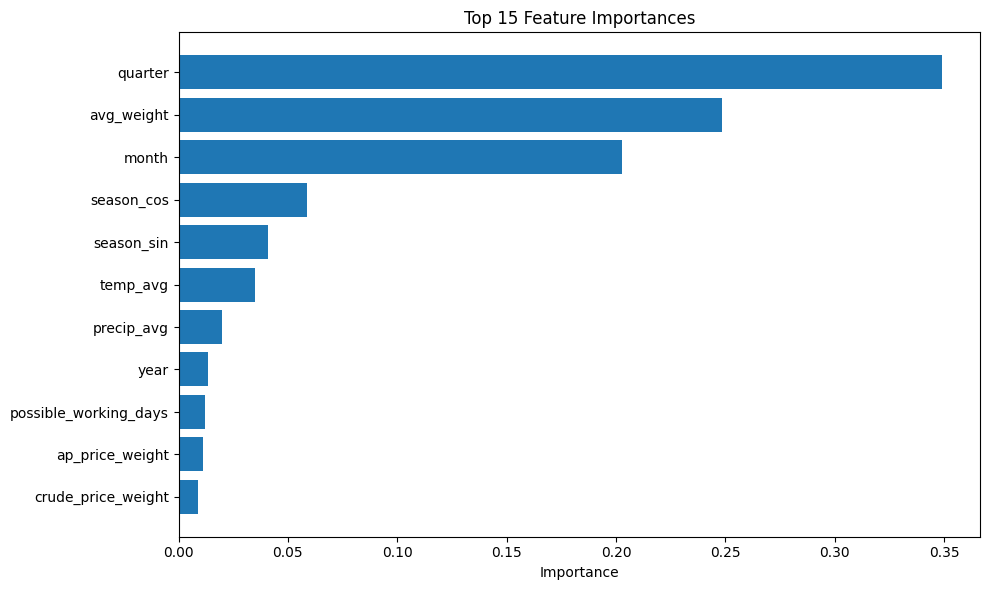

In [158]:
# Get feature importance
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'].head(15), feature_importance['importance'].head(15))
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 8. Visualize Predictions

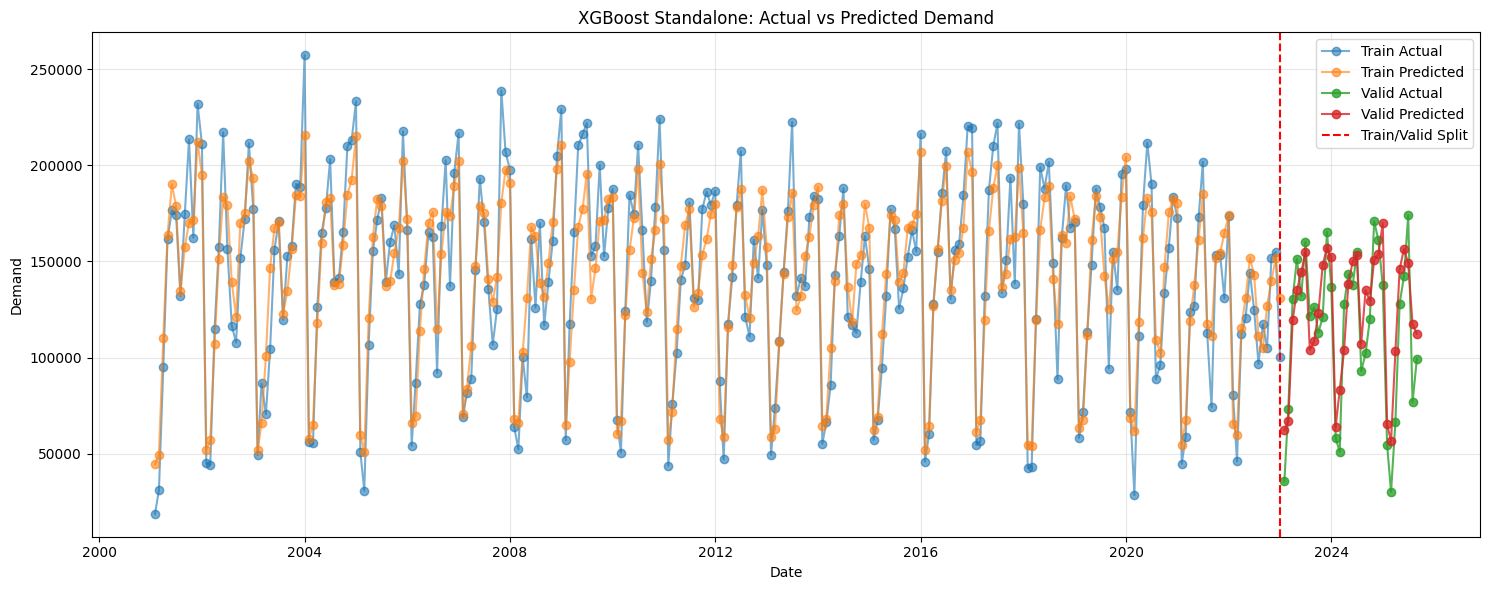

In [159]:
# Create visualization dataframe
viz_train = df_train.copy()
viz_train['prediction'] = train_pred
viz_train['set'] = 'train'

viz_valid = df_valid.copy()
viz_valid['prediction'] = valid_pred
viz_valid['set'] = 'valid'

viz = pd.concat([viz_train, viz_valid])

# Plot
plt.figure(figsize=(15, 6))
plt.plot(viz_train['ds'], viz_train['demand'], 'o-', label='Train Actual', alpha=0.6)
plt.plot(viz_train['ds'], viz_train['prediction'], 'o-', label='Train Predicted', alpha=0.6)
plt.plot(viz_valid['ds'], viz_valid['demand'], 'o-', label='Valid Actual', alpha=0.8)
plt.plot(viz_valid['ds'], viz_valid['prediction'], 'o-', label='Valid Predicted', alpha=0.8)
plt.axvline(x=cutoff, color='red', linestyle='--', label='Train/Valid Split')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.title('XGBoost Standalone: Actual vs Predicted Demand')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9. Save Model (Optional)

In [160]:
# Create models directory if it doesn't exist
import os
os.makedirs('../models', exist_ok=True)

# Save the model
model.save_model('../models/xgboost_standalone.json')
print("Model saved to ../models/xgboost_standalone.json")

# To load later:
# loaded_model = xgb.XGBRegressor()
# loaded_model.load_model('../models/xgboost_standalone.json')

Model saved to ../models/xgboost_standalone.json


### 10. Compare Results (Optional)

In [161]:
# Compare results from different feature sets
import glob

# Load all result files
result_files = glob.glob('../results/xgboost_*.json')

if len(result_files) > 0:
    comparison = []
    
    for file_path in result_files:
        with open(file_path, 'r') as f:
            data = json.load(f)
            comparison.append({
                'Model': data['model_name'],
                'Dataset': data['dataset'],
                'Features': data['num_features'],
                'Train RMSE': data['metrics']['training']['rmse'],
                'Valid RMSE': data['metrics']['validation']['rmse'],
                'Train MAPE': data['metrics']['training']['mape'],
                'Valid MAPE': data['metrics']['validation']['mape'],
                'Timestamp': data['timestamp']
            })
    
    # Create comparison dataframe
    comparison_df = pd.DataFrame(comparison)
    comparison_df = comparison_df.sort_values('Valid RMSE')
    
    print("Model Comparison:")
    print("="*80)
    print(comparison_df.to_string(index=False))
    print("\n" + "="*80)
    print(f"Best model: {comparison_df.iloc[0]['Model']}")
    print(f"Best Validation RMSE: {comparison_df.iloc[0]['Valid RMSE']:,.1f}")
else:
    print("No result files found yet. Run the notebook to generate results.")

Model Comparison:
                                    Model              Dataset  Features   Train RMSE   Valid RMSE  Train MAPE  Valid MAPE           Timestamp
XGBoost Standalone - final_features_2.csv final_features_2.csv        11 16762.566490 20078.040037   11.538245   20.582514 2025-12-04 21:29:32
XGBoost Standalone - final_features_1.csv final_features_1.csv        11 16707.996923 21174.658654   11.519822   21.382602 2025-12-04 21:26:10

Best model: XGBoost Standalone - final_features_2.csv
Best Validation RMSE: 20,078.0
